# 02 — Feature Engineering & Data Preparation

Ce notebook détaille la transformation des données brutes en un dataset structuré pour le Machine Learning. 

### Étapes clés :
1. **Unification des sources** : Jointure entre les données historiques (Kaggle) et les données live (Scraping API).
2. **Calcul de la Forme (Rolling Stats)** : Création de variables basées sur les 5 derniers matchs.
3. **Calcul de la Puissance (Elo Rating)** : Implémentation d'un système de notation dynamique.
4. **Enrichissement Betting** : Intégration des probabilités implicites des bookmakers.


In [1]:
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

# Ajout du root au path pour importer nos modules si besoin
sys.path.append(str(Path(os.getcwd()).parent.parent))

import psycopg
from psycopg.rows import dict_row

DATABASE_URL = os.getenv("DATABASE_URL", "postgresql://localhost:5432/l1_datalab")


## 1. Chargement des données depuis PostgreSQL

In [2]:
with psycopg.connect(DATABASE_URL, row_factory=dict_row) as conn:
    with conn.cursor() as cur:
        cur.execute("""
            SELECT m.id, m.season, m.kickoff, m.home_team_id, m.away_team_id, 
                   m.home_score, m.away_score, m.result,
                   ht.internal_name AS home_team, at_.internal_name AS away_team
            FROM matches m
            JOIN teams ht ON ht.id = m.home_team_id
            JOIN teams at_ ON at_.id = m.away_team_id
            ORDER BY m.kickoff ASC NULLS FIRST
        """)
        df = pd.DataFrame(cur.fetchall())

df['kickoff'] = pd.to_datetime(df['kickoff'], utc=True)
print(f"Total matchs chargés : {len(df)}")
df.head()

Total matchs chargés : 8098


,id,season,kickoff,home_team_id,away_team_id,home_score,away_score,result,home_team,away_team
0,7298,2006/07,NaT,28,4,1.0,0.0,H,stade-rennais,rc-lens
1,2,2000/01,NaT,2,1,1.0,3.0,A,olympique-de-marseille,paris-saint-germain
2,3,2000/01,NaT,4,2,0.0,0.0,D,rc-lens,olympique-de-marseille
3,4,1999/00,NaT,1,2,2.0,1.0,H,paris-saint-germain,olympique-de-marseille
4,5,1999/00,NaT,5,3,3.0,0.0,H,olympique-lyonnais,stade-de-reims


## 2. Focus sur l'Elo Rating
L'Elo Rating est notre feature la plus discriminante. Elle permet de quantifier la force d'une équipe non pas sur son nom, mais sur ses résultats réels pondérés par la force de ses adversaires.


In [3]:
# Visualisation des derniers scores Elo calculés
elos_path = '../features/match_elos.csv'
if os.path.exists(elos_path):
    df_elo = pd.read_csv(elos_path)
    print("Aperçu des scores Elo par match :")
    display(df_elo.head())
else:
    print("⚠️  Le fichier match_elos.csv n'a pas été trouvé. Lancez compute_elo.py d'abord.")

Aperçu des scores Elo par match :


,match_id,home_elo,away_elo
0,7363,1500.0,1500.0
1,2,1500.0,1500.0
2,3,1500.0,1484.0
3,4,1516.0,1484.7
4,5,1500.0,1500.0


## 3. Assemblage du Dataset ML Final

In [4]:
# Chargement du dataset généré par notre script create_ml_dataset.py
ml_path = '../features/ml_dataset.csv'
df_ml = pd.read_csv(ml_path)

print(f"Dimensions du dataset final : {df_ml.shape}")
print("\nListe des features générées :")
print(df_ml.columns.tolist())

Dimensions du dataset final : (8092, 27)

Liste des features générées :
['match_id', 'season', 'gameweek', 'status', 'home_team', 'away_team', 'home_elo', 'away_elo', 'elo_diff', 'home_form_5', 'home_goals_scored_5', 'home_goals_conceded_5', 'home_offensive_str', 'home_defensive_str', 'home_avg_overall', 'home_squad_value', 'away_form_5', 'away_goals_scored_5', 'away_goals_conceded_5', 'away_offensive_str', 'away_defensive_str', 'away_avg_overall', 'away_squad_value', 'odds_prob_home', 'odds_prob_draw', 'odds_prob_away', 'result']


## 4. Analyse de la cible (Result)

/var/folders/56/l_nsck090md8fschzkqhpblh0000gn/T/ipykernel_26964/650446864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='result', data=df_ml, order=['H', 'D', 'A'], palette='viridis')


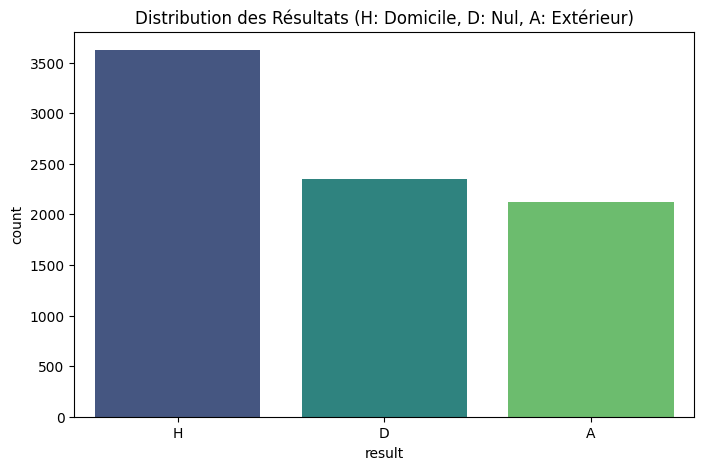

Proportions :
result
H    0.448
D    0.290
A    0.263
Name: proportion, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='result', data=df_ml, order=['H', 'D', 'A'], palette='viridis')
plt.title('Distribution des Résultats (H: Domicile, D: Nul, A: Extérieur)')
plt.show()

print("Proportions :")
print(df_ml['result'].value_counts(normalize=True).round(3))